In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import os
from pathlib import Path

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

In [3]:
# Define the main project folder
project_folder = Path( r"C:\NumpyNinja\Python\Hackathon\Python_Hackathon_Sep_2026\Python_Hackathon_Sep_2026")

# Define the folder containing the original datasets
raw_data_folder = project_folder /"raw_data"

# Define the folder for cleaned datasets and reports
output_folder = project_folder /"cleaned_data"

# Create the output folder if it does not already exist
output_folder.mkdir(exist_ok=True)

print("Project Folder:", project_folder)
print("Raw Data Folder:", raw_data_folder)
print("Output Folder:", output_folder)

Project Folder: C:\NumpyNinja\Python\Hackathon\Python_Hackathon_Sep_2026\Python_Hackathon_Sep_2026
Raw Data Folder: C:\NumpyNinja\Python\Hackathon\Python_Hackathon_Sep_2026\Python_Hackathon_Sep_2026\raw_data
Output Folder: C:\NumpyNinja\Python\Hackathon\Python_Hackathon_Sep_2026\Python_Hackathon_Sep_2026\cleaned_data


In [4]:
# Read the original Labs dataset
df = pd.read_csv(raw_data_folder / "hospitalization_discharge.csv")

# Keep an original copy
df_original = df.copy()

# Display the first five records
display(df.head())

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
df.head()
df.info()
df.describe()

,inpatient_number,destinationdischarge,admission_ward,admission_way,discharge_department,visit_times,respiratory_support,oxygen_inhalation,dischargeday,admission_date,outcome_during_hospitalization,death_within_28_days,re_admission_within_28_days,death_within_3_months,re_admission_within_3_months,death_within_6_months,re_admission_within_6_months,time_of_death__days_from_admission,readmission_time_days_from_admission,return_to_emergency_department_within_6_months,time_to_emergency_department_within_6_months
0,857781,Home,Cardiology,NonEmergency,Cardiology,1,NaN,OxygenTherapy,11,2017-01-24 00:00:00,Alive,0,0,0,0,0,0,NaN,NaN,0.0,NaN
1,743087,Home,Cardiology,NonEmergency,Cardiology,1,NaN,OxygenTherapy,8,2017-05-05 00:00:00,Alive,0,0,0,0,0,0,NaN,NaN,0.0,NaN
2,866418,Home,Cardiology,NonEmergency,Cardiology,2,NaN,OxygenTherapy,5,2016-11-18 00:00:00,Alive,0,0,0,0,0,0,NaN,NaN,0.0,NaN
3,775928,Home,Cardiology,Emergency,Cardiology,1,NaN,OxygenTherapy,11,2017-10-02 00:00:00,Alive,0,1,0,1,0,1,NaN,19.0,1.0,19.0
4,810128,Home,Cardiology,NonEmergency,Cardiology,1,NaN,OxygenTherapy,5,2019-11-17 00:00:00,Alive,0,0,0,0,0,0,NaN,NaN,0.0,NaN


Rows: 2008
Columns: 21
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2008 entries, 0 to 2007
Data columns (total 21 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   inpatient_number                                2008 non-null   int64  
 1   destinationdischarge                            2008 non-null   object 
 2   admission_ward                                  2008 non-null   object 
 3   admission_way                                   2008 non-null   object 
 4   discharge_department                            2008 non-null   object 
 5   visit_times                                     2008 non-null   int64  
 6   respiratory_support                             42 non-null     object 
 7   oxygen_inhalation                               2008 non-null   object 
 8   dischargeday                                    2008 non-null   int64  
 9   admission_date    

,inpatient_number,visit_times,dischargeday,death_within_28_days,re_admission_within_28_days,death_within_3_months,re_admission_within_3_months,death_within_6_months,re_admission_within_6_months,time_of_death__days_from_admission,readmission_time_days_from_admission,return_to_emergency_department_within_6_months,time_to_emergency_department_within_6_months
count,2008.000000,2008.000000,2008.000000,2008.000000,2008.000000,2008.000000,2008.000000,2008.000000,2008.000000,44.000000,901.000000,2007.000000,897.000000
mean,797747.542829,1.092629,9.420817,0.018426,0.069721,0.020916,0.248008,0.028386,0.384960,29.522727,126.711432,0.386148,126.734671
std,41127.801740,0.365946,8.030256,0.134521,0.254740,0.143140,0.431964,0.166116,0.486707,72.452226,145.025343,0.486987,145.100169
min,722128.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000
25%,763164.500000,1.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,42.000000,0.000000,42.000000
50%,798758.000000,1.000000,8.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.500000,83.000000,0.000000,83.000000
75%,829399.750000,1.000000,10.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,18.750000,166.000000,1.000000,166.000000
max,905720.000000,5.000000,123.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,350.000000,2280.000000,1.000000,2280.000000


In [5]:
df.head()

,inpatient_number,destinationdischarge,admission_ward,admission_way,discharge_department,visit_times,respiratory_support,oxygen_inhalation,dischargeday,admission_date,outcome_during_hospitalization,death_within_28_days,re_admission_within_28_days,death_within_3_months,re_admission_within_3_months,death_within_6_months,re_admission_within_6_months,time_of_death__days_from_admission,readmission_time_days_from_admission,return_to_emergency_department_within_6_months,time_to_emergency_department_within_6_months
0,857781,Home,Cardiology,NonEmergency,Cardiology,1,NaN,OxygenTherapy,11,2017-01-24 00:00:00,Alive,0,0,0,0,0,0,NaN,NaN,0.0,NaN
1,743087,Home,Cardiology,NonEmergency,Cardiology,1,NaN,OxygenTherapy,8,2017-05-05 00:00:00,Alive,0,0,0,0,0,0,NaN,NaN,0.0,NaN
2,866418,Home,Cardiology,NonEmergency,Cardiology,2,NaN,OxygenTherapy,5,2016-11-18 00:00:00,Alive,0,0,0,0,0,0,NaN,NaN,0.0,NaN
3,775928,Home,Cardiology,Emergency,Cardiology,1,NaN,OxygenTherapy,11,2017-10-02 00:00:00,Alive,0,1,0,1,0,1,NaN,19.0,1.0,19.0
4,810128,Home,Cardiology,NonEmergency,Cardiology,1,NaN,OxygenTherapy,5,2019-11-17 00:00:00,Alive,0,0,0,0,0,0,NaN,NaN,0.0,NaN


In [6]:
df.shape

(2008, 21)

In [7]:
#Inspect the column names
for column in df.columns:
    print(column)

inpatient_number
destinationdischarge
admission_ward
admission_way
discharge_department
visit_times
respiratory_support
oxygen_inhalation
dischargeday
admission_date
outcome_during_hospitalization
death_within_28_days
re_admission_within_28_days
death_within_3_months
re_admission_within_3_months
death_within_6_months
re_admission_within_6_months
time_of_death__days_from_admission
readmission_time_days_from_admission
return_to_emergency_department_within_6_months
time_to_emergency_department_within_6_months


In [8]:
# Checking for the datatypes
df.dtypes

inpatient_number                                    int64
destinationdischarge                               object
admission_ward                                     object
admission_way                                      object
discharge_department                               object
visit_times                                         int64
respiratory_support                                object
oxygen_inhalation                                  object
dischargeday                                        int64
admission_date                                     object
outcome_during_hospitalization                     object
death_within_28_days                                int64
re_admission_within_28_days                         int64
death_within_3_months                               int64
re_admission_within_3_months                        int64
death_within_6_months                               int64
re_admission_within_6_months                        int64
time_of_death_

In [9]:
df.describe()

#For both numerical and categorical columns:

,inpatient_number,visit_times,dischargeday,death_within_28_days,re_admission_within_28_days,death_within_3_months,re_admission_within_3_months,death_within_6_months,re_admission_within_6_months,time_of_death__days_from_admission,readmission_time_days_from_admission,return_to_emergency_department_within_6_months,time_to_emergency_department_within_6_months
count,2008.000000,2008.000000,2008.000000,2008.000000,2008.000000,2008.000000,2008.000000,2008.000000,2008.000000,44.000000,901.000000,2007.000000,897.000000
mean,797747.542829,1.092629,9.420817,0.018426,0.069721,0.020916,0.248008,0.028386,0.384960,29.522727,126.711432,0.386148,126.734671
std,41127.801740,0.365946,8.030256,0.134521,0.254740,0.143140,0.431964,0.166116,0.486707,72.452226,145.025343,0.486987,145.100169
min,722128.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000
25%,763164.500000,1.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,42.000000,0.000000,42.000000
50%,798758.000000,1.000000,8.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.500000,83.000000,0.000000,83.000000
75%,829399.750000,1.000000,10.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,18.750000,166.000000,1.000000,166.000000
max,905720.000000,5.000000,123.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,350.000000,2280.000000,1.000000,2280.000000


In [10]:
df.describe(include='all').T
#The .T transposes the output so each variable appears on its own row.

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
inpatient_number,2008.0,NaN,NaN,NaN,797747.542829,41127.80174,722128.0,763164.5,798758.0,829399.75,905720.0
destinationdischarge,2008,4,Home,1344,NaN,NaN,NaN,NaN,NaN,NaN,NaN
admission_ward,2008,4,Cardiology,1547,NaN,NaN,NaN,NaN,NaN,NaN,NaN
admission_way,2008,2,NonEmergency,1052,NaN,NaN,NaN,NaN,NaN,NaN,NaN
discharge_department,2008,4,Cardiology,1703,NaN,NaN,NaN,NaN,NaN,NaN,NaN
visit_times,2008.0,NaN,NaN,NaN,1.092629,0.365946,1.0,1.0,1.0,1.0,5.0
respiratory_support,42,2,IMV,25,NaN,NaN,NaN,NaN,NaN,NaN,NaN
oxygen_inhalation,2008,2,OxygenTherapy,1898,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dischargeday,2008.0,NaN,NaN,NaN,9.420817,8.030256,1.0,6.0,8.0,10.0,123.0
admission_date,2008,1100,2018-06-20 00:00:00,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
# Check for duplicate records
df.duplicated().sum()

np.int64(0)

In [12]:
# check for duplicate patient/inpatient numbers:
df['inpatient_number'].duplicated().sum()
# In dataset, the inpatient numbers are unique.

np.int64(0)

In [13]:
# Check missing values

df.isnull().sum()

inpatient_number                                     0
destinationdischarge                                 0
admission_ward                                       0
admission_way                                        0
discharge_department                                 0
visit_times                                          0
respiratory_support                               1966
oxygen_inhalation                                    0
dischargeday                                         0
admission_date                                       0
outcome_during_hospitalization                       0
death_within_28_days                                 0
re_admission_within_28_days                          0
death_within_3_months                                0
re_admission_within_3_months                         0
death_within_6_months                                0
re_admission_within_6_months                         0
time_of_death__days_from_admission                1964
readmissio

In [14]:
# For a cleaner report:
missing = pd.DataFrame({
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': df.isnull().mean() * 100
})

missing.sort_values('Missing_Percentage', ascending=False)

,Missing_Count,Missing_Percentage
respiratory_support,1966,97.908367
time_of_death__days_from_admission,1964,97.808765
time_to_emergency_department_within_6_months,1111,55.328685
readmission_time_days_from_admission,1107,55.129482
return_to_emergency_department_within_6_months,1,0.049801
death_within_28_days,0,0.000000
re_admission_within_6_months,0,0.000000
death_within_6_months,0,0.000000
re_admission_within_3_months,0,0.000000
death_within_3_months,0,0.000000


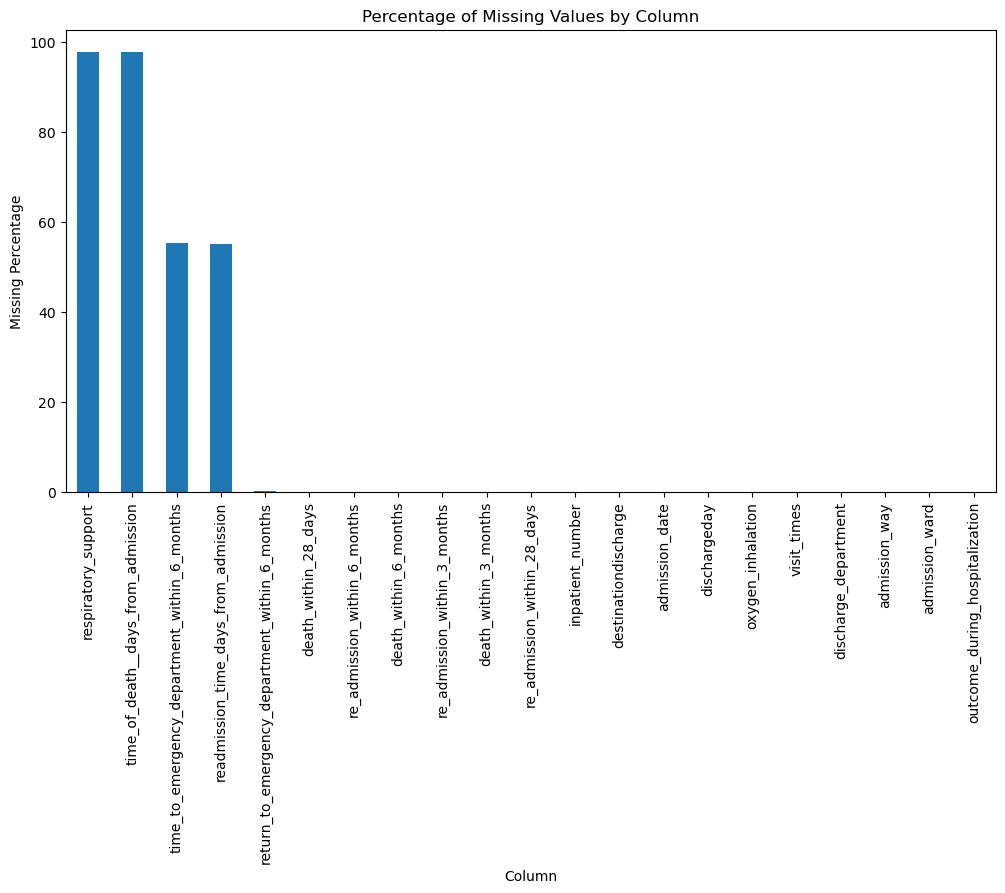

In [18]:
# Visualize missing values
missing_percentage = df.isnull().mean() * 100

missing_percentage = missing_percentage.sort_values(ascending=False)

plt.figure(figsize=(12, 6))
missing_percentage.plot(kind='bar')

plt.title('Percentage of Missing Values by Column')
plt.ylabel('Missing Percentage')
plt.xlabel('Column')
plt.xticks(rotation=90)
plt.show()

In [15]:
# Examine categorical variables
categorical_columns = df.select_dtypes(include='object').columns

for column in categorical_columns:
    print("\n", column)
    print(df[column].value_counts(dropna=False))


 destinationdischarge
destinationdischarge
Home                  1344
HealthcareFacility     438
Unknown                212
Died                    14
Name: count, dtype: int64

 admission_ward
admission_ward
Cardiology     1547
GeneralWard     265
Others          181
ICU              15
Name: count, dtype: int64

 admission_way
admission_way
NonEmergency    1052
Emergency        956
Name: count, dtype: int64

 discharge_department
discharge_department
Cardiology     1703
GeneralWard     241
Others           52
ICU              12
Name: count, dtype: int64

 respiratory_support
respiratory_support
NaN     1966
IMV       25
NIMV      17
Name: count, dtype: int64

 oxygen_inhalation
oxygen_inhalation
OxygenTherapy    1898
AmbientAir        110
Name: count, dtype: int64

 admission_date
admission_date
2018-06-20 00:00:00    6
2018-04-30 00:00:00    6
2017-03-29 00:00:00    6
2017-04-21 00:00:00    6
2017-10-31 00:00:00    5
                      ..
2016-01-27 00:00:00    1
2016-10-05 00:

In [16]:
# Check for inconsistent text values
df['destinationdischarge'].unique()

array(['Home', 'HealthcareFacility', 'Unknown', 'Died'], dtype=object)

In [23]:
# Do for the others
df['admission_ward'].unique()


array(['Cardiology', 'GeneralWard', 'ICU', 'Others'], dtype=object)

In [24]:
df['admission_way'].unique()


array(['NonEmergency', 'Emergency'], dtype=object)

In [25]:
df['discharge_department'].unique()


array(['Cardiology', 'Others', 'GeneralWard', 'ICU'], dtype=object)

In [26]:
df['respiratory_support'].unique()


array([nan, 'NIMV', 'IMV'], dtype=object)

In [27]:
df['oxygen_inhalation'].unique()

array(['OxygenTherapy', 'AmbientAir'], dtype=object)

In [28]:
# Convert the admission date to Date time
df['admission_date'].dtype

dtype('<M8[ns]')

In [29]:
df['admission_date'] = pd.to_datetime(
    df['admission_date'],
    errors='coerce'
)

In [30]:
df['admission_date'].dtype

dtype('<M8[ns]')

In [19]:
# Checking whether date conversion created missing values
df['admission_date'].isnull().sum()

np.int64(0)

In [31]:
# Checking the date range
print("Earliest admission:", df['admission_date'].min())
print("Latest admission:", df['admission_date'].max())

Earliest admission: 2016-01-01 00:00:00
Latest admission: 2019-12-30 00:00:00


In [34]:
# Checking numerical variables for unusual values
numeric_columns = df.select_dtypes(include=np.number).columns

numeric_columns

Index(['inpatient_number', 'visit_times', 'dischargeday',
       'death_within_28_days', 're_admission_within_28_days',
       'death_within_3_months', 're_admission_within_3_months',
       'death_within_6_months', 're_admission_within_6_months',
       'time_of_death__days_from_admission',
       'readmission_time_days_from_admission',
       'return_to_emergency_department_within_6_months',
       'time_to_emergency_department_within_6_months'],
      dtype='object')

In [35]:
# Define numeric columns
df[numeric_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
inpatient_number,2008.0,797747.542829,41127.801740,722128.0,763164.5,798758.0,829399.75,905720.0
visit_times,2008.0,1.092629,0.365946,1.0,1.0,1.0,1.00,5.0
dischargeday,2008.0,9.420817,8.030256,1.0,6.0,8.0,10.00,123.0
death_within_28_days,2008.0,0.018426,0.134521,0.0,0.0,0.0,0.00,1.0
re_admission_within_28_days,2008.0,0.069721,0.254740,0.0,0.0,0.0,0.00,1.0
death_within_3_months,2008.0,0.020916,0.143140,0.0,0.0,0.0,0.00,1.0
re_admission_within_3_months,2008.0,0.248008,0.431964,0.0,0.0,0.0,0.00,1.0
death_within_6_months,2008.0,0.028386,0.166116,0.0,0.0,0.0,0.00,1.0
re_admission_within_6_months,2008.0,0.384960,0.486707,0.0,0.0,0.0,1.00,1.0
time_of_death__days_from_admission,44.0,29.522727,72.452226,1.0,2.0,4.5,18.75,350.0


In [37]:
# Investigate dischargeday
df['dischargeday'].sort_values(ascending=False).head(20)

884     123
1613    118
1549     88
1573     82
1513     76
1345     73
579      64
1908     63
484      62
470      62
811      57
1511     57
1860     56
442      54
183      54
1063     50
108      50
1228     46
1852     42
509      41
Name: dischargeday, dtype: int64

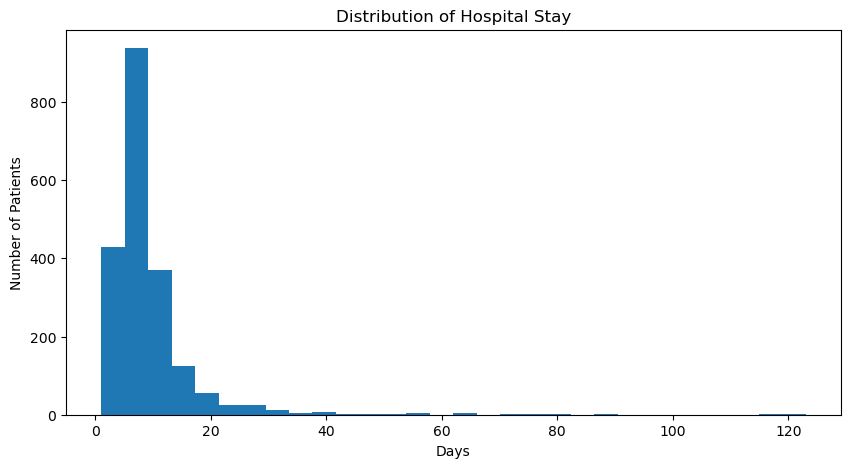

In [38]:
# Check the distribution of length of stay
plt.figure(figsize=(10, 5))

plt.hist(df['dischargeday'], bins=30)

plt.title('Distribution of Hospital Stay')
plt.xlabel('Days')
plt.ylabel('Number of Patients')

plt.show()

In [39]:
# Check the binary variables
# Several columns are essentially Yes/No variables represented as 0 and 1.
# For example:
# death_within_28_days
# re_admission_within_28_days
# death_within_3_months
# re_admission_within_3_months
# death_within_6_months
# re_admission_within_6_months

binary_columns = [
    'death_within_28_days',
    're_admission_within_28_days',
    'death_within_3_months',
    're_admission_within_3_months',
    'death_within_6_months',
    're_admission_within_6_months',
    'return_to_emergency_department_within_6_months'
]

for column in binary_columns:
    print("\n", column)
    print(df[column].value_counts(dropna=False))


 death_within_28_days
death_within_28_days
0    1971
1      37
Name: count, dtype: int64

 re_admission_within_28_days
re_admission_within_28_days
0    1868
1     140
Name: count, dtype: int64

 death_within_3_months
death_within_3_months
0    1966
1      42
Name: count, dtype: int64

 re_admission_within_3_months
re_admission_within_3_months
0    1510
1     498
Name: count, dtype: int64

 death_within_6_months
death_within_6_months
0    1951
1      57
Name: count, dtype: int64

 re_admission_within_6_months
re_admission_within_6_months
0    1235
1     773
Name: count, dtype: int64

 return_to_emergency_department_within_6_months
return_to_emergency_department_within_6_months
0.0    1232
1.0     775
NaN       1
Name: count, dtype: int64


In [40]:
# Checking logical consistency
# For example, if:
# death_within_28_days = 1
# then:
# time_of_death__days_from_admission

df[
    (df['death_within_28_days'] == 1) &
    (df['time_of_death__days_from_admission'].isna())
]

,inpatient_number,destinationdischarge,admission_ward,admission_way,discharge_department,visit_times,respiratory_support,oxygen_inhalation,dischargeday,admission_date,outcome_during_hospitalization,death_within_28_days,re_admission_within_28_days,death_within_3_months,re_admission_within_3_months,death_within_6_months,re_admission_within_6_months,time_of_death__days_from_admission,readmission_time_days_from_admission,return_to_emergency_department_within_6_months,time_to_emergency_department_within_6_months


In [41]:
# Also checking below:
df[
    (df['death_within_28_days'] == 0) &
    (df['time_of_death__days_from_admission'].notna())
]

,inpatient_number,destinationdischarge,admission_ward,admission_way,discharge_department,visit_times,respiratory_support,oxygen_inhalation,dischargeday,admission_date,outcome_during_hospitalization,death_within_28_days,re_admission_within_28_days,death_within_3_months,re_admission_within_3_months,death_within_6_months,re_admission_within_6_months,time_of_death__days_from_admission,readmission_time_days_from_admission,return_to_emergency_department_within_6_months,time_to_emergency_department_within_6_months
76,736369,Unknown,Cardiology,NonEmergency,Cardiology,1,NaN,OxygenTherapy,10,2016-01-10,Alive,0,0,1,0,1,0,35.0,NaN,0.0,NaN
470,811749,Died,Cardiology,NonEmergency,Cardiology,2,NaN,OxygenTherapy,62,2017-01-24,Dead,0,0,1,0,1,0,62.0,NaN,0.0,NaN
1361,810379,Home,Cardiology,NonEmergency,Cardiology,2,NaN,OxygenTherapy,8,2016-03-03,Alive,0,0,1,0,1,0,52.0,NaN,0.0,NaN
1880,834500,Home,Cardiology,NonEmergency,Cardiology,4,NaN,OxygenTherapy,5,2018-08-09,Alive,0,0,0,1,0,1,238.0,42.0,1.0,42.0
1881,828595,HealthcareFacility,Cardiology,Emergency,Cardiology,3,NaN,OxygenTherapy,6,2019-08-12,Alive,0,0,0,1,0,1,269.0,31.0,1.0,31.0
1882,812759,Home,Others,NonEmergency,Cardiology,2,NaN,OxygenTherapy,12,2016-07-14,Alive,0,0,0,1,0,1,350.0,81.0,1.0,81.0
1997,750447,Died,Cardiology,NonEmergency,Cardiology,1,IMV,OxygenTherapy,29,2019-07-01,Dead,0,0,1,0,1,0,29.0,NaN,0.0,NaN


In [42]:
# Checking emergency-department consistency
df[
    (df['return_to_emergency_department_within_6_months'] == 1) &
    (df['time_to_emergency_department_within_6_months'].isna())
]

,inpatient_number,destinationdischarge,admission_ward,admission_way,discharge_department,visit_times,respiratory_support,oxygen_inhalation,dischargeday,admission_date,outcome_during_hospitalization,death_within_28_days,re_admission_within_28_days,death_within_3_months,re_admission_within_3_months,death_within_6_months,re_admission_within_6_months,time_of_death__days_from_admission,readmission_time_days_from_admission,return_to_emergency_department_within_6_months,time_to_emergency_department_within_6_months
9,829801,Home,Cardiology,NonEmergency,Cardiology,1,NaN,OxygenTherapy,4,2018-01-30,Alive,0,0,0,0,0,0,NaN,NaN,1.0,NaN
58,794078,Home,Cardiology,NonEmergency,Cardiology,1,NaN,OxygenTherapy,9,2017-11-28,Alive,0,0,0,0,0,1,NaN,183.0,1.0,NaN
110,734027,Home,Cardiology,NonEmergency,Cardiology,1,NaN,OxygenTherapy,8,2017-09-14,Alive,0,0,0,1,0,1,NaN,60.0,1.0,NaN
261,823432,Unknown,Cardiology,Emergency,Cardiology,1,NaN,OxygenTherapy,1,2019-02-08,Alive,0,0,0,1,0,1,NaN,31.0,1.0,NaN
274,738813,Home,Cardiology,Emergency,Cardiology,1,NaN,OxygenTherapy,21,2018-09-20,Alive,0,0,0,1,0,1,NaN,58.0,1.0,NaN
884,794077,Home,GeneralWard,Emergency,GeneralWard,1,NaN,OxygenTherapy,123,2016-05-19,Alive,0,0,0,0,0,0,NaN,NaN,1.0,NaN
1381,839952,Home,Cardiology,NonEmergency,Cardiology,1,NaN,OxygenTherapy,5,2019-04-17,Alive,0,0,0,0,0,0,NaN,NaN,1.0,NaN


In [43]:
# And
df[
    (df['return_to_emergency_department_within_6_months'] == 0) &
    (df['time_to_emergency_department_within_6_months'].notna())
]
# This is an example of domain-based data validation.

,inpatient_number,destinationdischarge,admission_ward,admission_way,discharge_department,visit_times,respiratory_support,oxygen_inhalation,dischargeday,admission_date,outcome_during_hospitalization,death_within_28_days,re_admission_within_28_days,death_within_3_months,re_admission_within_3_months,death_within_6_months,re_admission_within_6_months,time_of_death__days_from_admission,readmission_time_days_from_admission,return_to_emergency_department_within_6_months,time_to_emergency_department_within_6_months
30,743467,Home,Cardiology,NonEmergency,Cardiology,1,NaN,OxygenTherapy,7,2018-11-18,Alive,0,0,0,0,0,0,NaN,310.0,0.0,310.0
48,806646,HealthcareFacility,Cardiology,Emergency,Cardiology,1,NaN,OxygenTherapy,6,2019-01-04,Alive,0,0,0,0,0,0,NaN,463.0,0.0,463.0
71,778545,HealthcareFacility,Cardiology,NonEmergency,Cardiology,1,NaN,OxygenTherapy,8,2019-12-10,Alive,0,0,0,0,0,0,NaN,207.0,0.0,207.0
84,782224,HealthcareFacility,Cardiology,NonEmergency,Cardiology,1,NaN,OxygenTherapy,7,2018-01-26,Alive,0,0,0,0,0,0,NaN,183.0,0.0,183.0
92,788057,HealthcareFacility,Cardiology,NonEmergency,Cardiology,1,NaN,OxygenTherapy,7,2016-09-04,Alive,0,0,0,0,0,0,NaN,192.0,0.0,192.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1975,801155,Home,Cardiology,Emergency,Cardiology,1,NaN,OxygenTherapy,12,2019-10-30,Alive,0,0,0,0,0,0,NaN,244.0,0.0,244.0
1982,739217,Home,Cardiology,Emergency,Cardiology,1,NaN,AmbientAir,8,2019-02-13,Alive,0,0,0,0,0,0,NaN,186.0,0.0,186.0
1985,776559,Home,Cardiology,NonEmergency,Cardiology,1,NaN,OxygenTherapy,12,2016-04-29,Alive,0,0,0,0,0,0,NaN,495.0,0.0,495.0
1992,729142,Home,Cardiology,NonEmergency,Cardiology,1,NaN,OxygenTherapy,9,2016-06-21,Alive,0,0,0,0,0,0,NaN,305.0,0.0,305.0


In [44]:
# Handle return_to_emergency_department... missing value
# return_to_emergency_department_within_6_months

# Change this value to 0
df[
    df['return_to_emergency_department_within_6_months'].isna()
]

,inpatient_number,destinationdischarge,admission_ward,admission_way,discharge_department,visit_times,respiratory_support,oxygen_inhalation,dischargeday,admission_date,outcome_during_hospitalization,death_within_28_days,re_admission_within_28_days,death_within_3_months,re_admission_within_3_months,death_within_6_months,re_admission_within_6_months,time_of_death__days_from_admission,readmission_time_days_from_admission,return_to_emergency_department_within_6_months,time_to_emergency_department_within_6_months
1446,822437,Unknown,Others,NonEmergency,Others,1,NaN,OxygenTherapy,2,2018-12-12,Alive,0,0,0,0,0,0,NaN,NaN,NaN,NaN


In [45]:
# Checking respiratory support column
# 1966 missing
# 25 IMV
# 17 NIMV

df['respiratory_support'].fillna('None')

0       None
1       None
2       None
3       None
4       None
        ... 
2003    None
2004    None
2005    None
2006     IMV
2007    None
Name: respiratory_support, Length: 2008, dtype: object

In [46]:
df['respiratory_support'].value_counts(dropna=False)

respiratory_support
NaN     1966
IMV       25
NIMV      17
Name: count, dtype: int64

In [48]:
# Creating an additional variable if the documentation supports missing value in 
# respiratory_support mean 'no respiratory support'
# check this one what would it create

df['respiratory_support_known'] = df['respiratory_support'].notna().astype(int)

In [49]:
# Cleaning column names like destinationdischarge, re_admission_within_28_days,
# time_of_death__days_from_admission
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_')
    .str.replace('__', '_')
)


In [50]:
# Checking columns names which I have changed
df.columns

Index(['inpatient_number', 'destinationdischarge', 'admission_ward',
       'admission_way', 'discharge_department', 'visit_times',
       'respiratory_support', 'oxygen_inhalation', 'dischargeday',
       'admission_date', 'outcome_during_hospitalization',
       'death_within_28_days', 're_admission_within_28_days',
       'death_within_3_months', 're_admission_within_3_months',
       'death_within_6_months', 're_admission_within_6_months',
       'time_of_death_days_from_admission',
       'readmission_time_days_from_admission',
       'return_to_emergency_department_within_6_months',
       'time_to_emergency_department_within_6_months',
       'respiratory_support_known'],
      dtype='object')

In [51]:
# Converting datatype binary columns to integers
for column in binary_columns:
    if column in df.columns:
        df[column] = df[column].astype('Int64')

In [46]:
# Create the output folder if it does not exist
output_folder.mkdir(exist_ok=True)

# Full path for the output CSV file
output_file = output_folder / "Team7_CodeAvengers_Category1_DataCleaning_hospitalization_discharge.csv"

# Save the cleaned dataset INTO the output folder
df.to_csv(output_file, index=False)

# Display the saved files and their locations
print("All files saved successfully!\n")

for file in output_folder.iterdir():
    if file.is_file():
        print("Saved:", file.name)

# Print full absolute path of the saved CSV
print("\nFull Output File Path:", output_file.resolve())

print("Output Folder:", output_folder.resolve())
print("Final Cleaned Dataset Shape:", df.shape)


All files saved successfully!

Saved: Team7_CodeAvengers_Category1_DataCleaning_hospitalization_discharge.csv

Full Output File Path: C:\Users\sandy\output\Team7_CodeAvengers_Category1_DataCleaning_hospitalization_discharge.csv
Output Folder: C:\Users\sandy\output
Final Cleaned Dataset Shape: (2008, 21)


In [38]:
print("Hello")

Hello


In [39]:
from pathlib import Path

In [40]:
output_folder = Path("output")

In [41]:
output_folder.mkdir(exist_ok=True)

In [42]:
df.to_csv("cleaned.csv", index=False)

In [43]:
df.to_csv("Team7_CodeAvengers_Category1_DataCleaning_hospitalization_discharge.csv", index=False)